In [3]:
import pandas as pd

df = pd.read_csv(r"C:\Users\ACER\Downloads\SuperMarket Dataset\Superstore.csv", encoding='latin-1')

print(df['Order ID'].nunique())   # unique order IDs
print(len(df))       

5009
9994


In [4]:
# Find orders that appear more than once
print(df[df['Order ID'] == 'CA-2016-152156'][['Order ID', 'Product ID', 'Category', 'Sales']])

         Order ID       Product ID   Category   Sales
0  CA-2016-152156  FUR-BO-10001798  Furniture  261.96
1  CA-2016-152156  FUR-CH-10000454  Furniture  731.94


In [7]:
# Check if composite key is truly unique
duplicates = df.duplicated(subset=['Order ID', 'Product ID'])
print(duplicates.sum())

8


In [8]:
# Find the actual duplicate rows
mask = df.duplicated(subset=['Order ID', 'Product ID'], keep=False)
dupes = df[mask].sort_values(['Order ID', 'Product ID'])
print(dupes[['Order ID', 'Product ID', 'Sales', 'Quantity', 'Profit']].to_string())

            Order ID       Product ID     Sales  Quantity    Profit
6498  CA-2015-103135  OFF-BI-10000069   135.090         9   62.1414
6500  CA-2015-103135  OFF-BI-10000069    90.060         6   41.4276
350   CA-2016-129714  OFF-PA-10001970    24.560         2   11.5432
352   CA-2016-129714  OFF-PA-10001970    49.120         4   23.0864
1300  CA-2016-137043  FUR-FU-10003664   572.760         6  166.1004
1301  CA-2016-137043  FUR-FU-10003664   286.380         3   83.0502
9168  CA-2016-140571  OFF-PA-10001954   319.760        14  147.0896
9169  CA-2016-140571  OFF-PA-10001954    45.680         2   21.0128
7881  CA-2017-118017  TEC-AC-10002006    76.752         6   10.5534
7882  CA-2017-118017  TEC-AC-10002006   102.336         8   14.0712
3183  CA-2017-152912  OFF-ST-10003208  1633.140         9  473.6106
3184  CA-2017-152912  OFF-ST-10003208   544.380         3  157.8702
3405  US-2014-150119  FUR-CH-10002965   281.372         2  -12.0588
3406  US-2014-150119  FUR-CH-10002965   281.372 

In [11]:
df.groupby('Order ID')['Sales'].sum()

Order ID
CA-2014-100006     377.970
CA-2014-100090     699.192
CA-2014-100293      91.056
CA-2014-100328       3.928
CA-2014-100363      21.376
                    ...   
US-2017-168802      18.368
US-2017-169320     171.430
US-2017-169488      56.860
US-2017-169502     113.410
US-2017-169551    1344.838
Name: Sales, Length: 5009, dtype: float64

In [12]:
# Drop identical duplicate first
df = df.drop_duplicates(subset=['Order ID', 'Product ID'], keep='first')

# Verify
print(f"Rows remaining: {len(df)}")
print(f"Duplicates left: {df.duplicated(subset=['Order ID', 'Product ID']).sum()}")


Rows remaining: 9986
Duplicates left: 0


In [15]:
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [17]:
# Check for nulls disguised as strings
print(df[df['Order Date'] == '']['Order Date'].count())
print(df[df['Order Date'] == 'N/A']['Order Date'].count())
print(df[df['Order Date'] == 'null']['Order Date'].count())

0
0
0


In [19]:
print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)

object
object


In [21]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(df['Order Date'].dtype)

datetime64[ns]


In [23]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter

In [25]:
df['Ship Duration'] = (df['Ship Date'] - df['Order Date']).dt.days
print(df['Ship Duration'].describe())

count    9986.000000
mean        3.958542
std         1.747875
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Ship Duration, dtype: float64


In [27]:
df.to_csv('superstore_cleaned.csv', index=False)

In [28]:
from sqlalchemy import create_engine

engine = create_engine('sqlite:///superstore.db')
df.to_sql('sales', engine, if_exists='replace', index=False)
print("Database created successfully")

Database created successfully


In [30]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///superstore.db')

query = """
SELECT 
    Year,
    Quarter,
    ROUND(SUM(Sales), 2) as Total_Sales
FROM sales
GROUP BY Year, Quarter
ORDER BY Total_Sales DESC
LIMIT 5
"""

result = pd.read_sql(query, engine)
print(result)

   Year  Quarter  Total_Sales
0  2017        4    279407.35
1  2016        4    235812.37
2  2017        3    196251.96
3  2015        4    182297.01
4  2014        4    179627.73


In [31]:
engine = create_engine('sqlite:///superstore.db')
query = """
SELECT 
    [Order ID],
    ROUND(SUM(Profit), 2) as Profit_Per_Order
FROM sales
GROUP BY [Order ID]
ORDER BY Profit_Per_Order ASC
LIMIT 10
"""

result = pd.read_sql(query, engine)
print(result)

         Order ID  Profit_Per_Order
0  CA-2016-108196          -6892.37
1  US-2017-168116          -3825.34
2  CA-2014-169019          -3791.16
3  CA-2017-134845          -3424.35
4  US-2017-122714          -2929.48
5  CA-2017-131254          -2330.27
6  CA-2015-147830          -1980.38
7  CA-2014-139892          -1878.79
8  CA-2015-116638          -1862.31
9  CA-2016-130946          -1790.27


In [34]:
print(df[df['Order ID'] == 'CA-2016-108196'][['Product Name', 'Sales', 'Discount', 'Profit']])


                                          Product Name     Sales  Discount  \
7771  GBC Ibimaster 500 Manual ProClick Binding System   456.588       0.7   
7772         Cubify CubeX 3D Printer Double Head Print  4499.985       0.7   
7773          NETGEAR RangeMax WNR1000 Wireless Router    59.976       0.2   

         Profit  
7771  -304.3920  
7772 -6599.9780  
7773    11.9952  


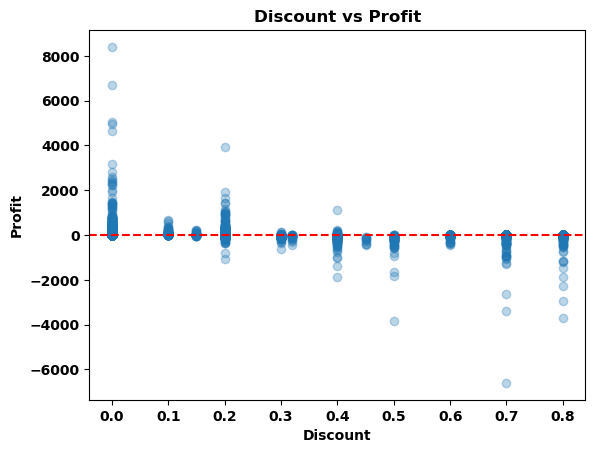

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df['Discount'], df['Profit'], alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Discount vs Profit')
plt.show()


In [38]:

engine = create_engine('sqlite:///superstore.db')

query = """
SELECT 
    Category,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Profit
FROM sales 
GROUP BY Category
ORDER BY Total_Sales DESC
LIMIT 10
"""

result = pd.read_sql(query, engine)
print(result)

          Category  Total_Sales     Profit
0       Technology    835759.74  145386.13
1        Furniture    741432.04   18380.28
2  Office Supplies    718317.79  122247.40


In [39]:

engine = create_engine('sqlite:///superstore.db')

query = """
SELECT 
    Region,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Profit
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC
LIMIT 10
"""

result = pd.read_sql(query, engine)
print(result)

    Region  Total_Sales     Profit
0     West    725355.49  108404.38
1     East    677906.37   91353.88
2  Central    501239.89   39706.36
3    South    391007.83   46549.20


In [41]:
engine = create_engine('sqlite:///superstore.db')

query = """
SELECT 
    `Sub-Category`,
    ROUND(SUM(Sales), 2) as Total_Sales,
    ROUND(SUM(Profit), 2) as Total_Profit
FROM sales
GROUP BY `Sub-Category`
ORDER BY Total_Profit ASC
"""

result = pd.read_sql(query, engine)
print(result)

   Sub-Category  Total_Sales  Total_Profit
0        Tables    206965.53     -17725.48
1     Bookcases    114880.00      -3472.56
2      Supplies     46673.54      -1189.10
3     Fasteners      3024.28        949.52
4      Machines    189238.63       3384.76
5        Labels     12486.31       5546.25
6           Art     27118.79       6527.79
7     Envelopes     16476.40       6964.18
8   Furnishings     91418.78      12976.09
9    Appliances    107532.16      18138.01
10      Storage    223299.23      21120.96
11       Chairs    328167.73      26602.23
12      Binders    203322.67      30180.34
13        Paper     78384.41      34009.47
14  Accessories    166986.02      41867.82
15       Phones    330007.05      44515.73
16      Copiers    149528.03      55617.82


In [45]:
# Save aggregated tables for Power BI
quarterly_sales = df.groupby(['Year', 'Quarter']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

regional_sales = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

category_sales = df.groupby(['Category', 'Sub-Category']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()

# Export
quarterly_sales.to_csv('quarterly_sales.csv', index=False)
regional_sales.to_csv('regional_sales.csv', index=False)
category_sales.to_csv('category_sales.csv', index=False)
df.to_csv('superstore_cleaned1.csv', index=False)

print("All files exported successfully!")

All files exported successfully!


In [47]:
engine = create_engine('sqlite:///superstore.db')

query = """
select 
    [sub-category], 
    region, 
    sum(profit) as Profit
from sales 
group by [sub-category], region
order by Profit ASC
"""

result = pd.read_sql(query, engine)
print(result)

   Sub-Category   Region      Profit
0        Tables     East -11025.3801
1        Tables    South  -4623.0579
2   Furnishings  Central  -3906.2168
3        Tables  Central  -3559.6504
4    Appliances  Central  -2638.6175
..          ...      ...         ...
63      Copiers  Central  15608.8413
64      Binders     West  16096.8016
65  Accessories     West  16470.5271
66      Copiers     East  17022.8418
67      Copiers     West  19327.2351

[68 rows x 3 columns]


In [49]:
engine = create_engine('sqlite:///superstore.db')

query = """
SELECT 
    Year,
    Quarter,
    Category,
    ROUND(SUM(Sales), 2) as Total_Sales
FROM sales
GROUP BY Year, Quarter, Category
ORDER BY Year, Quarter, Total_Sales DESC
"""

result = pd.read_sql(query, engine)
print(result)

    Year  Quarter         Category  Total_Sales
0   2014        1       Technology     37262.97
1   2014        1        Furniture     22656.14
2   2014        1  Office Supplies     14528.68
3   2014        2  Office Supplies     31243.74
4   2014        2        Furniture     27782.38
5   2014        2       Technology     27231.28
6   2014        3  Office Supplies     53923.97
7   2014        3       Technology     47751.37
8   2014        3        Furniture     41957.88
9   2014        4        Furniture     64515.09
10  2014        4       Technology     63032.62
11  2014        4  Office Supplies     52080.03
12  2015        1        Furniture     27374.10
13  2015        1  Office Supplies     23059.39
14  2015        1       Technology     18418.25
15  2015        2  Office Supplies     32320.04
16  2015        2       Technology     29239.32
17  2015        2        Furniture     27564.83
18  2015        3        Furniture     49586.04
19  2015        3       Technology     4